In [7]:
from ultralytics import YOLO
import pandas as pd

## Pose Estimation and Preparing Dataset

In [8]:
source="squat2.mov"  # Sample image for testing
model = YOLO("yolo11n-pose.pt")
class_names = model.names  # Store model classes names
results = model(source=source, stream=True)

In [9]:
KEYPOINT_NAMES = [
    'Nose', 'Left Eye', 'Right Eye', 'Left Ear', 'Right Ear',
    'Left Shoulder', 'Right Shoulder', 'Left Elbow', 'Right Elbow',
    'Left Wrist', 'Right Wrist', 'Left Hip', 'Right Hip',
    'Left Knee', 'Right Knee', 'Left Ankle', 'Right Ankle'
]

data = []

for result in results:
    kpt_list = result.keypoints.xy                 # keypoints for all objects
    kpt = kpt_list[0]
    
    frame_data = []
    for x, y in kpt.tolist(): 
        frame_data.append((x, y))
    
    data.append(frame_data)
    


video 1/1 (frame 1/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 57.8ms
video 1/1 (frame 2/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 61.5ms
video 1/1 (frame 3/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 53.8ms
video 1/1 (frame 4/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 54.5ms
video 1/1 (frame 5/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 55.7ms
video 1/1 (frame 6/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 55.7ms
video 1/1 (frame 7/81) /Users/zhantian/Documents/GitHub/Body-Movement-Prediction-with-Time-Series/squat2.mov: 640x384 1 person, 55.5ms
video 1/1 (frame 8/81) /Users/zhantian/Documents/GitHu

In [15]:
df = pd.DataFrame(data)
df.columns = KEYPOINT_NAMES
df.head(20)

,Nose,Left Eye,Right Eye,Left Ear,Right Ear,Left Shoulder,Right Shoulder,Left Elbow,Right Elbow,Left Wrist,Right Wrist,Left Hip,Right Hip,Left Knee,Right Knee,Left Ankle,Right Ankle
0,"(557.370849609375, 635.5557861328125)","(556.905029296875, 616.091064453125)","(538.6420288085938, 620.564208984375)","(517.7963256835938, 622.4647216796875)","(483.10223388671875, 636.97314453125)","(443.1387939453125, 712.1187133789062)","(465.0188903808594, 726.8720703125)","(556.0472412109375, 775.4827880859375)","(632.297119140625, 792.9031372070312)","(684.8699951171875, 813.5684204101562)","(797.6239624023438, 800.5406494140625)","(277.8878479003906, 972.45263671875)","(286.3826904296875, 984.4482421875)","(524.1817626953125, 1014.2344970703125)","(537.5333862304688, 1036.146240234375)","(413.15655517578125, 1234.260986328125)","(400.5293884277344, 1266.3978271484375)"
1,"(556.8175048828125, 641.437255859375)","(555.1422119140625, 622.338134765625)","(538.3451538085938, 626.294921875)","(513.3493041992188, 629.3623046875)","(481.9368591308594, 642.9439697265625)","(441.583740234375, 720.4677734375)","(460.8661804199219, 734.2348022460938)","(552.1937255859375, 780.4487915039062)","(626.2794799804688, 796.90185546875)","(673.1234741210938, 820.1248168945312)","(792.1306762695312, 806.2035522460938)","(275.2459716796875, 982.3201904296875)","(281.79876708984375, 994.13671875)","(526.183837890625, 1017.2490844726562)","(536.9606323242188, 1039.3790283203125)","(409.547119140625, 1237.3101806640625)","(398.0262145996094, 1269.74365234375)"
2,"(556.8065185546875, 641.1422729492188)","(555.0614624023438, 622.0306396484375)","(538.3154296875, 626.0447387695312)","(513.1577758789062, 629.1016845703125)","(481.97528076171875, 642.8782958984375)","(441.4325256347656, 720.4154663085938)","(461.0107727050781, 734.291259765625)","(552.1318359375, 780.4962158203125)","(626.2627563476562, 797.016845703125)","(672.8821411132812, 820.072021484375)","(792.0431518554688, 806.2855224609375)","(274.7429504394531, 982.275390625)","(281.5458068847656, 994.1067504882812)","(525.6222534179688, 1017.2080688476562)","(536.8746337890625, 1039.3709716796875)","(409.17584228515625, 1237.2779541015625)","(398.10882568359375, 1269.9066162109375)"
3,"(555.0630493164062, 645.8919677734375)","(552.6212768554688, 626.4457397460938)","(536.7587280273438, 630.6005249023438)","(508.9921569824219, 632.8035278320312)","(481.7401428222656, 647.4368286132812)","(436.5721740722656, 725.8275146484375)","(463.99481201171875, 740.2366943359375)","(543.0714111328125, 784.6871337890625)","(628.9640502929688, 801.7446899414062)","(658.8727416992188, 823.3272094726562)","(788.7854614257812, 812.1322631835938)","(268.6575927734375, 987.654052734375)","(280.5472106933594, 999.3599243164062)","(522.583251953125, 1015.421142578125)","(536.6854858398438, 1037.45263671875)","(404.916748046875, 1237.2630615234375)","(395.5157775878906, 1270.6884765625)"
4,"(555.0768432617188, 645.8630981445312)","(552.6314697265625, 626.4022827148438)","(536.7813110351562, 630.5499267578125)","(509.02825927734375, 632.7671508789062)","(481.77972412109375, 647.3595581054688)","(436.70355224609375, 725.9273681640625)","(463.9471740722656, 740.1717529296875)","(543.335693359375, 784.8538818359375)","(628.8597412109375, 801.7175903320312)","(659.114013671875, 823.2167358398438)","(788.8299560546875, 812.2050170898438)","(268.5627746582031, 987.6630249023438)","(280.36590576171875, 999.2997436523438)","(522.4346313476562, 1015.5676879882812)","(536.7295532226562, 1037.51708984375)","(404.71112060546875, 1237.474853515625)","(395.676025390625, 1270.931640625)"
5,"(554.65576171875, 650.5098266601562)","(551.5278930664062, 631.0823364257812)","(536.76513671875, 635.2642822265625)","(506.5553894042969, 637.0759887695312)","(482.195556640625, 651.9490356445312)","(435.24920654296875, 729.23486328125)","(464.84393310546875, 745.4638671875)","(551.67138671875, 783.2088623046875)","(631.4231567382812, 805.2409057617188)","(6

## Analyze Data and Select Lag

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#### In order to access individual x and y data of each keypoint, we need to seperate (x, y) and assign them to their own column

In [40]:
rows = []
for frame_data in data:
    row = {}
    for i, (x, y) in enumerate(frame_data):
        keypoint_name = KEYPOINT_NAMES[i]
        row[f'{keypoint_name} x'] = x
        row[f'{keypoint_name} y'] = y
    rows.append(row)

df = pd.DataFrame(rows)
df.head(20)

,Nose x,Nose y,Left Eye x,Left Eye y,Right Eye x,Right Eye y,Left Ear x,Left Ear y,Right Ear x,Right Ear y,...,Right Hip x,Right Hip y,Left Knee x,Left Knee y,Right Knee x,Right Knee y,Left Ankle x,Left Ankle y,Right Ankle x,Right Ankle y
0,557.370850,635.555786,556.905029,616.091064,538.642029,620.564209,517.796326,622.464722,483.102234,636.973145,...,286.382690,984.448242,524.181763,1014.234497,537.533386,1036.146240,413.156555,1234.260986,400.529388,1266.397827
1,556.817505,641.437256,555.142212,622.338135,538.345154,626.294922,513.349304,629.362305,481.936859,642.943970,...,281.798767,994.136719,526.183838,1017.249084,536.960632,1039.379028,409.547119,1237.310181,398.026215,1269.743652
2,556.806519,641.142273,555.061462,622.030640,538.315430,626.044739,513.157776,629.101685,481.975281,642.878296,...,281.545807,994.106750,525.622253,1017.208069,536.874634,1039.370972,409.175842,1237.277954,398.108826,1269.906616
3,555.063049,645.891968,552.621277,626.445740,536.758728,630.600525,508.992157,632.803528,481.740143,647.436829,...,280.547211,999.359924,522.583252,1015.421143,536.685486,1037.452637,404.916748,1237.263062,395.515778,1270.688477
4,555.076843,645.863098,552.631470,626.402283,536.781311,630.549927,509.028259,632.767151,481.779724,647.359558,...,280.365906,999.299744,522.434631,1015.567688,536.729553,1037.517090,404.711121,1237.474854,395.676025,1270.931641
5,554.655762,650.509827,551.527893,631.082336,536.765137,635.264282,506.555389,637.075989,482.195557,651.949036,...,280.803650,1005.530090,522.974670,1012.197388,538.611389,1035.226074,404.642029,1235.118652,395.717163,1268.347046
6,554.671509,650.490051,551.549377,631.094788,536.804688,635.246521,506.607635,637.129517,482.236145,651.907898,...,280.834686,1005.381714,523.186523,1012.190735,538.404358,1035.138672,405.565887,1235.123413,396.039490,1268.235718
7,552.303833,656.908813,551.055359,636.560120,533.846191,640.371155,510.100281,641.434448,478.438721,654.634216,...,278.439301,1011.013123,529.631714,1010.096741,544.562256,1032.530640,409.120697,1237.639526,400.594482,1268.176758
8,552.285522,656.877441,551.025879,636.545410,533.822144,640.354004,510.096100,641.441406,478.398132,654.618469,...,278.378693,1011.005737,529.624084,1010.023865,544.442688,1032.428223,409.086395,1237.536377,400.570740,1268.091309
9,551.230591,659.013245,550.075439,639.252319,532.017456,642.765747,510.807129,646.179138,476.295380,658.810852,...,277.821381,1015.545471,531.861389,1011.159973,543.789062,1033.147583,410.063416,1237.591431,402.477203,1267.710083


#### Let's use Right Knee's y position as an example

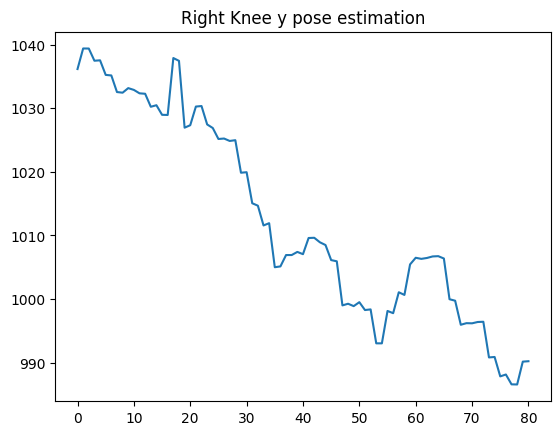

In [28]:
plt.plot(df['Right Knee y'])
plt.title("Right Knee y pose estimation")
plt.show()

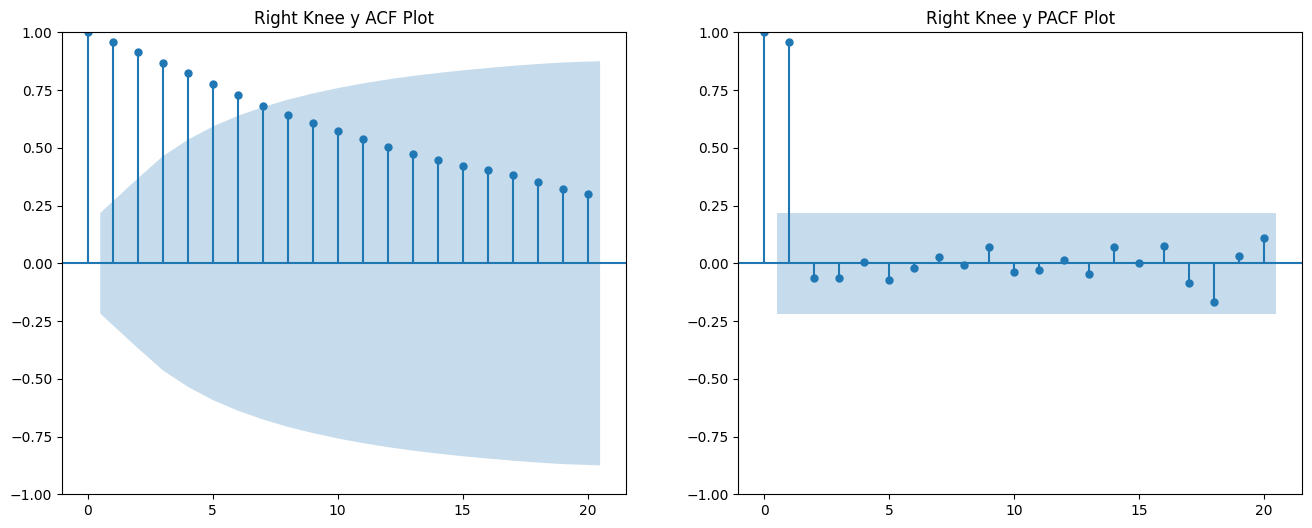

In [41]:
# Plot ACF and PACF to visualize the optimal lag
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF plot
plot_acf(df['Right Knee y'], ax=axes[0], lags=20)
axes[0].set_title('Right Knee y ACF Plot')

# PACF plot
plot_pacf(df['Right Knee y'], ax=axes[1], lags=20, method='ywm')
axes[1].set_title('Right Knee y PACF Plot')

plt.show()

In [ ]:
#https://www.geeksforgeeks.org/machine-learning/what-is-lag-in-time-series-forecasting/

# Function to fit ARIMA models with different p (lags) and return AIC scores
def select_best_lag(Right_Knee_y, max_lag):
    aic_values = []
    
    for p in range(1, max_lag + 1):
        model = ARIMA(Right_Knee_y, order=(p, 0, 0))  # ARIMA(p, d, q) where d=0 for AR model
        model_fit = model.fit()
        aic_values.append((p, model_fit.aic))
        
    return aic_values

# Set max_lag to try and get the best lag based on AIC
max_lag = 10
aic_scores = select_best_lag(df['Right Knee y'], max_lag)

# Print the AIC values for different lags
for lag, aic in aic_scores:
    print(f'Lag: {lag}, AIC: {aic}')

# Find the lag with the minimum AIC value
best_lag = min(aic_scores, key=lambda x: x[1])[0]
print(f'\nOptimal Lag based on AIC: {best_lag}')

Lag: 1, AIC: 405.5416577146636
Lag: 2, AIC: 407.5423218700018
Lag: 3, AIC: 409.5319492885089
Lag: 4, AIC: 411.5311602310556
Lag: 5, AIC: 410.82049815884915
Lag: 6, AIC: 412.381782051844
Lag: 7, AIC: 414.3813640853911
Lag: 8, AIC: 416.2440049397467
Lag: 9, AIC: 417.67758934643524
Lag: 10, AIC: 419.62841665638007

Optimal Lag based on AIC: 1
